In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [9]:
# Load the CSV files
df1 = pd.read_csv("csvs/results_36813.csv")
df2 = pd.read_csv("csvs/results_52841.csv")
df3 = pd.read_csv("csvs/results_83308.csv")

df = pd.concat([df1, df2, df3], ignore_index=True)

In [10]:
df.head(15)

,file,type,dataset,detected_count,time_ns,first_x,first_y,first_w,first_h
0,1187019.jpg,Brazil,DS1,4,455877600,2031,1516,160,53
1,1187019_labelled.jpg,Brazil,DS1,5,233408100,1809,1336,142,47
2,1792023.jpg,Brazil,DS1,2,236193100,3245,1367,134,45
3,1792023_labelled.jpg,Brazil,DS1,2,265463400,3245,1368,131,44
4,2114000.jpg,Brazil,DS1,10,301261200,1891,1979,261,87
5,2114000_labelled.jpg,Brazil,DS1,7,254974600,1872,988,122,41
6,2148000.jpg,Brazil,DS1,8,217561700,1873,1973,287,96
7,2148000_labelled.jpg,Brazil,DS1,8,252261100,1871,1972,289,96
8,2154018.jpg,Brazil,DS1,4,321291200,561,1585,323,108
9,2154018_labelled.jpg,Brazil,DS1,3,230862200,575,1591,281,94


In [11]:
sns.set(style="whitegrid")

In [12]:
df['dataset'] = df['dataset'].astype('category')
df['type'] = df['type'].astype('category')

df['time_ns'] = pd.to_numeric(df['time_ns'], errors='coerce')
df['detected_count'] = pd.to_numeric(df['detected_count'], errors='coerce')

In [13]:
print("\n=== Estatísticas Descritivas ===")
print(df.describe())


=== Estatísticas Descritivas ===
       detected_count       time_ns       first_x       first_y       first_w  \
count    16740.000000  1.674000e+04  16740.000000  16740.000000  16740.000000   
mean         0.675448  2.866223e+07    170.137754    171.478973     71.398984   
std          1.505664  6.608155e+07    404.806391    338.935119    127.495655   
min          0.000000  5.244000e+05      0.000000      0.000000      0.000000   
25%          0.000000  3.525850e+06      0.000000      0.000000      0.000000   
50%          0.000000  9.992100e+06      0.000000      0.000000      0.000000   
75%          1.000000  2.405418e+07    188.000000    249.000000    137.000000   
max         33.000000  7.193278e+08   5674.000000   3874.000000   2248.000000   

            first_h  
count  16740.000000  
mean      23.794803  
std       42.495912  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%       46.000000  
max      749.000000  


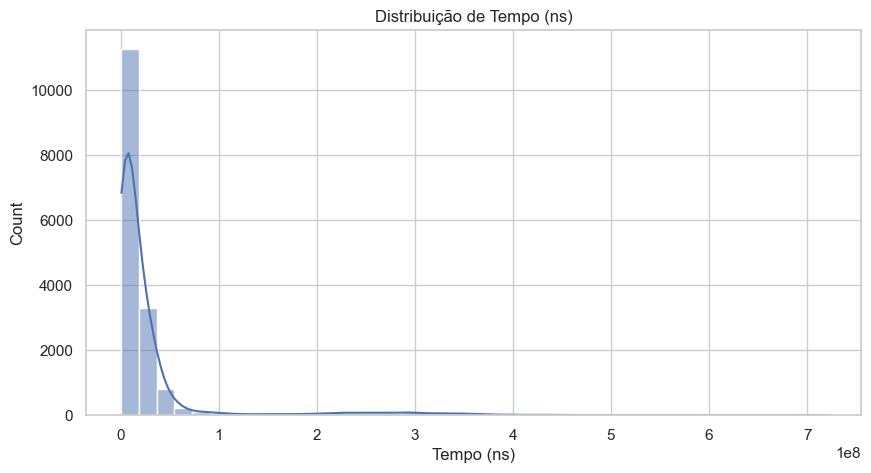

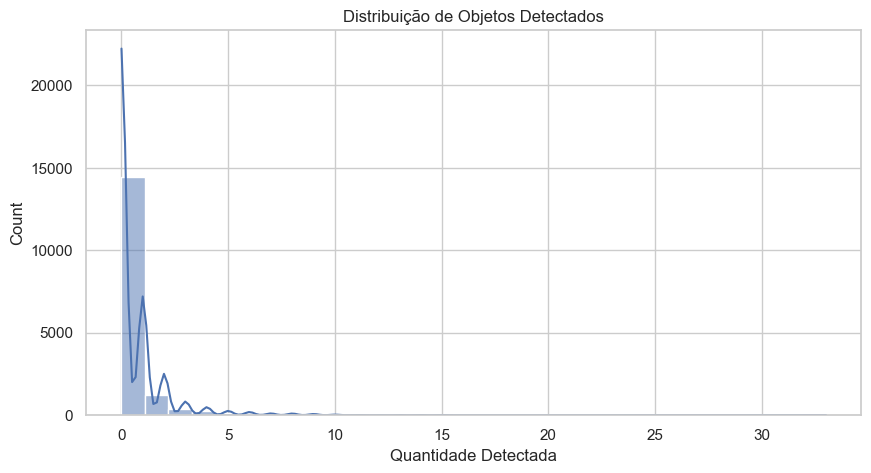

In [14]:
# Histograma do tempo
plt.figure(figsize=(10,5))
sns.histplot(df['time_ns'], kde=True, bins=40)
plt.title("Distribuição de Tempo (ns)")
plt.xlabel("Tempo (ns)")
plt.show()

# Histograma da quantidade detectada
plt.figure(figsize=(10,5))
sns.histplot(df['detected_count'], kde=True, bins=30)
plt.title("Distribuição de Objetos Detectados")
plt.xlabel("Quantidade Detectada")
plt.show()


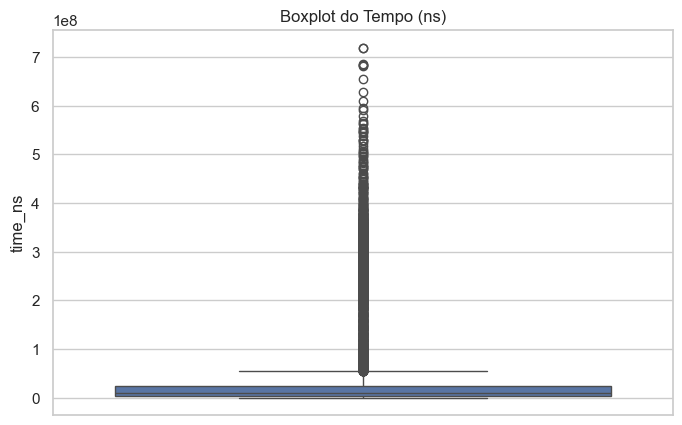

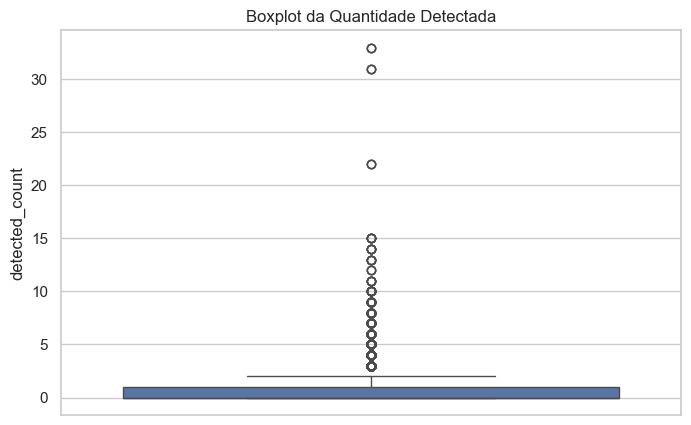

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['time_ns'])
plt.title("Boxplot do Tempo (ns)")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(y=df['detected_count'])
plt.title("Boxplot da Quantidade Detectada")
plt.show()


C:\Users\maria\AppData\Local\Temp\ipykernel_62712\892988395.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['time_ns'], shade=True)


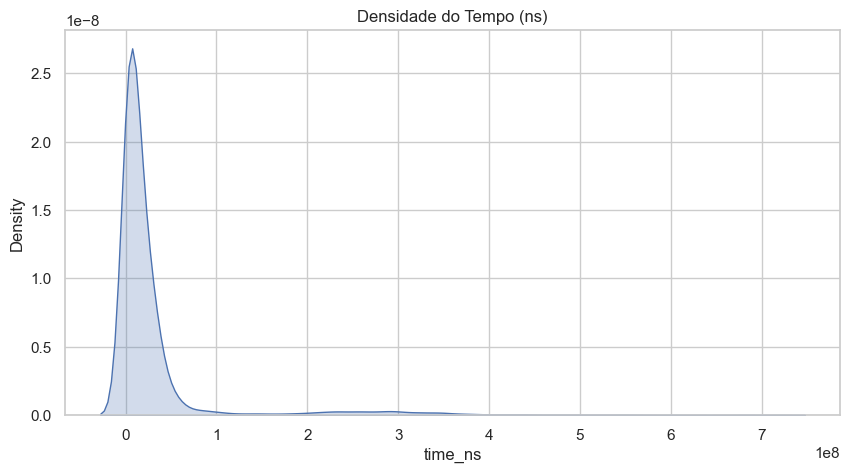

C:\Users\maria\AppData\Local\Temp\ipykernel_62712\892988395.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['detected_count'], shade=True)


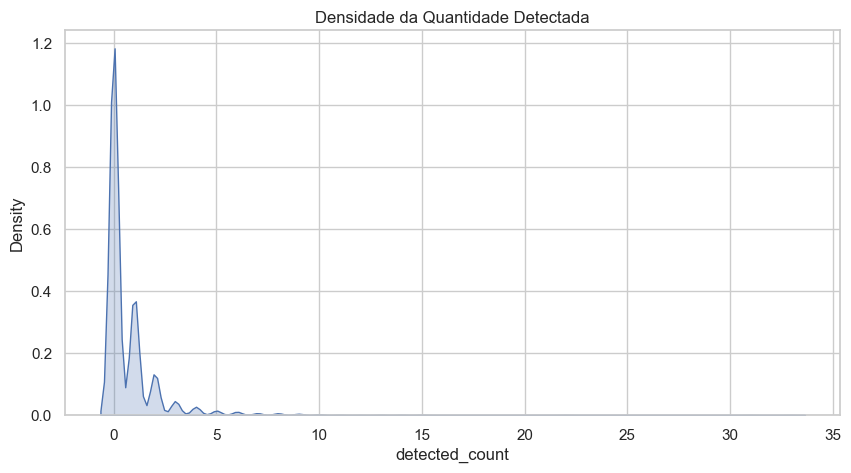

In [16]:
plt.figure(figsize=(10,5))
sns.kdeplot(df['time_ns'], shade=True)
plt.title("Densidade do Tempo (ns)")
plt.show()

plt.figure(figsize=(10,5))
sns.kdeplot(df['detected_count'], shade=True)
plt.title("Densidade da Quantidade Detectada")
plt.show()


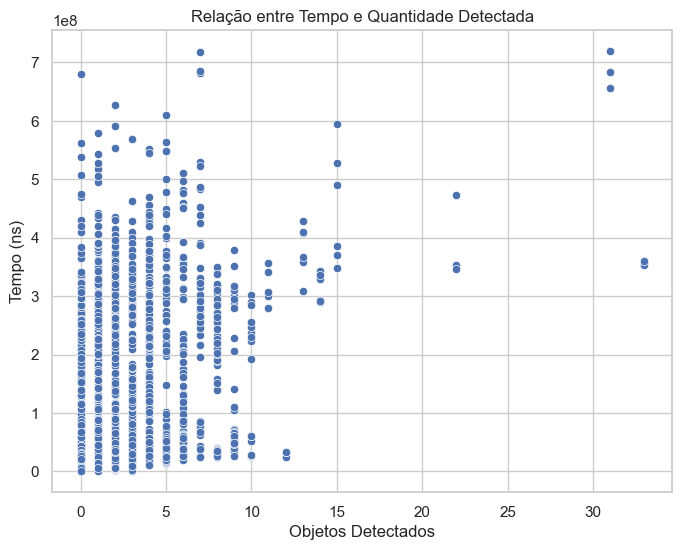

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='detected_count', y='time_ns')
plt.title("Relação entre Tempo e Quantidade Detectada")
plt.xlabel("Objetos Detectados")
plt.ylabel("Tempo (ns)")
plt.show()


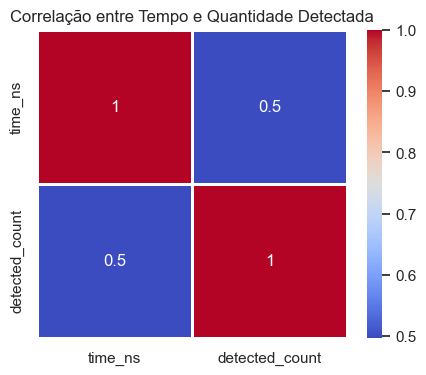

In [18]:
corr = df[['time_ns', 'detected_count']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=1)
plt.title("Correlação entre Tempo e Quantidade Detectada")
plt.show()


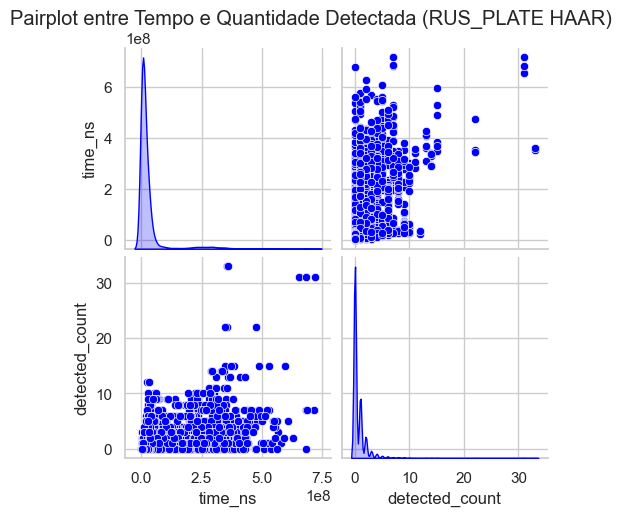

In [24]:

g = sns.pairplot(df[['time_ns', 'detected_count']],
                    plot_kws={'color': 'blue'},
                    diag_kws={'color': 'blue'},
                     diag_kind='kde')
g.fig.suptitle("Pairplot entre Tempo e Quantidade Detectada (RUS_PLATE HAAR)", y=1.02)

plt.show()


In [20]:
df['z_time'] = (df['time_ns'] - df['time_ns'].mean()) / df['time_ns'].std()

outliers = df[df['z_time'].abs() > 3]

print("\n=== OUTLIERS DE TEMPO ===")
print(outliers[['file','dataset','time_ns','detected_count','z_time']])



=== OUTLIERS DE TEMPO ===
                                 file dataset    time_ns  detected_count  \
0                         1187019.jpg     DS1  455877600               4   
1                1187019_labelled.jpg     DS1  233408100               5   
2                         1792023.jpg     DS1  236193100               2   
3                1792023_labelled.jpg     DS1  265463400               2   
4                         2114000.jpg     DS1  301261200              10   
...                               ...     ...        ...             ...   
16619   f9a571f7-EdGCgfyfO5qQN0O6.jpg     DS2  406763300               1   
16626  f9fed384-hHYc34U0YnmeDVRL.jpeg     DS2  511551200               6   
16694  fd9ee6e5-3TwDPMiea275UC0v.jpeg     DS2  253042000               0   
16713  fe6ef983-uWuZ3zV81xwYX3Pf.jpeg     DS2  260071800               1   
16726  ff4b034d-qDymZqnKTru5q4s2.jpeg     DS2  369887600              15   

         z_time  
0      6.464972  
1      3.098382  
2     

In [22]:
estat = {
    "media_time_ns": df['time_ns'].mean(),
    "mediana_time_ns": df['time_ns'].median(),
    "std_time_ns": df['time_ns'].std(),
    "media_detected": df['detected_count'].mean(),
    "mediana_detected": df['detected_count'].median(),
    "std_detected": df['detected_count'].std(),
}

print("\n=== ESTATÍSTICAS RESUMIDAS ===")
for k, v in estat.items():
    if "time" in k:
        # Converte Nanosegundos para Milissegundos (dividir por 1 milhão)
        # Ex: 15.000.000 ns -> 15.00 ms
        valor_ms = v / 1_000_000.0
        print(f"{k:<20}: {valor_ms:.4f} ms") # .4f = 4 casas decimais
    elif "detected" in k:
        # Quantidade de objetos detectados
        print(f"{k:<20}: {v:.4f} detecções/img")


=== ESTATÍSTICAS RESUMIDAS ===
media_time_ns       : 28.6622 ms
mediana_time_ns     : 9.9921 ms
std_time_ns         : 66.0815 ms
media_detected      : 0.6754 detecções/img
mediana_detected    : 0.0000 detecções/img
std_detected        : 1.5057 detecções/img


```
=== ESTATÍSTICAS RESUMIDAS  (RUS_PLATE HAAR ) - PYTHON ===
media_time_ns       : 28.6622 ms
mediana_time_ns     : 9.9921 ms
std_time_ns         : 66.0815 ms
media_detected      : 0.6754 detecções/img
mediana_detected    : 0.0000 detecções/img
std_detected        : 1.5057 detecções/img